In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
# Return (metric, relaxed_metric)
def get_metrics(task: str) -> tuple[str]:
    from eval.vqa import TASKS

    metrics, relaxed_metrics = TASKS[task].METRICS, TASKS[task].RELAXED_METRICS
    assert len(metrics) == 1 and len(relaxed_metrics) == 1
    return (metrics[0], relaxed_metrics[0])


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["size"] = run.config["n_bits"] / (8 * 10**6)
    fmt = run.config["quantisation"]["fmt"]
    _type = fmt["_type"]
    if _type == "linear":
        d["fmt"] = fmt["element_format"]["_type"]
        if d["fmt"] == "lut":
            name = fmt["element_format"]["name"]
            df = int(name.split("[")[1].split("]")[0])
            d["fmt"] = f"student-t [df={df}]"

    elif _type == "fit_scaled" and fmt["element_family"] == "t":
        d["fmt"] = "student-t [fit]"
    else:
        raise ValueError

    # d["fmt"] = run.config["quantisation"]["fmt"]

    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m, relaxed_m = get_metrics(task)
        d[task] = run.summary[f"downstream.{task}.{m}"]
        d[f"{task}_relaxed"] = run.summary[f"downstream.{task}.{relaxed_m}"]

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [4]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "formats-19-02-26", "state": "finished"},
)

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])
# df = df.drop_duplicates()

In [6]:
df

,name,size,fmt,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss
0,dauntless-brook-1617,3007.199270,int,0.000326,0.094401,0.039062,0.058594,0.000000,0.003906,0.000000,0.004883,0.881230,0.966444
1,unique-cloud-1618,4007.194310,int,0.308919,0.623372,0.066406,0.092773,0.030273,0.361328,0.024266,0.243164,0.162925,0.174950
2,cerulean-tree-1619,4673.857670,int,0.555664,0.772786,0.566406,0.620117,0.638672,0.855469,0.397530,0.861328,0.035187,0.035055
3,glad-glade-1619,3340.530950,int,0.000651,0.111328,0.008789,0.013672,0.000000,0.008789,0.000000,0.011719,0.716792,0.774367
4,usual-grass-1621,4173.860150,int,0.520833,0.767253,0.356445,0.415039,0.518555,0.827148,0.305093,0.816406,0.049114,0.049766
5,sweet-deluge-1622,5340.521030,int,0.666341,0.773112,0.594727,0.663086,0.639648,0.855469,0.656841,0.871094,0.028454,0.028137
6,spring-dust-1623,5883.039133,fp,0.728841,0.780599,0.642578,0.679688,0.725586,0.890625,0.842696,0.913086,0.009493,0.009836
7,smart-rain-1624,5383.041613,fp,0.676432,0.781901,0.650391,0.680664,0.666992,0.888672,0.604767,0.916992,0.010857,0.010144
8,valiant-morning-1625,6549.702493,fp,0.706706,0.779622,0.664062,0.712891,0.728516,0.890625,0.819828,0.917969,0.008522,0.009078
9,ethereal-sea-1626,4340.525990,int,0.587240,0.757812,0.548828,0.643555,0.635742,0.838867,0.272992,0.833984,0.041811,0.042840


In [7]:
# Baseline runs:
# - ethereal-shape-1606: quantised, no training
# - whole-fire-1607: bfloat16

baseline_runs = runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "baseline-12-02-26", "state": "finished"},
)
baseline = {}
step_0 = {}

for run in runs:
    # Check I'm using the right quantisation for step = 0 baseline
    if run.config["quantisation"] == runs[0].config["quantisation"]:
        assert run.config["training"]["n_steps"] == 0
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            step_0[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

    # bfloat16 baseline
    if (
        run.config["quantisation"]["fmt"]["_type"] == "torch"
        and run.config["quantisation"]["fmt"]["dtype"] == "bfloat16"
    ):
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            baseline[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

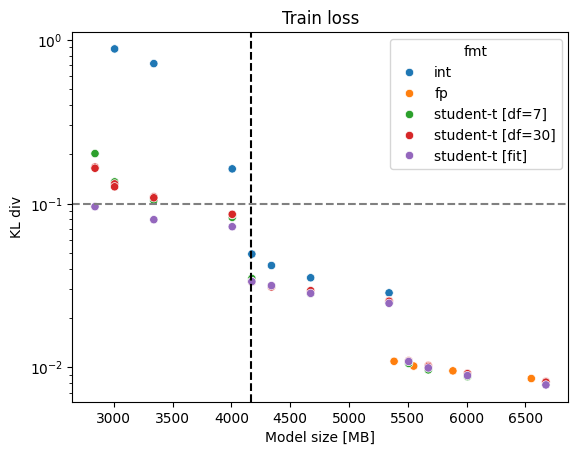

In [8]:
sns.scatterplot(data=df, x="size", y="train_loss", hue="fmt")
plt.title("Train loss")
plt.xlabel("Model size [MB]")
plt.ylabel("KL div")
plt.yscale("log")
plt.axvline(4170, linestyle="--", color="black")
plt.axhline(0.1, linestyle="--", color="grey")
plt.show()

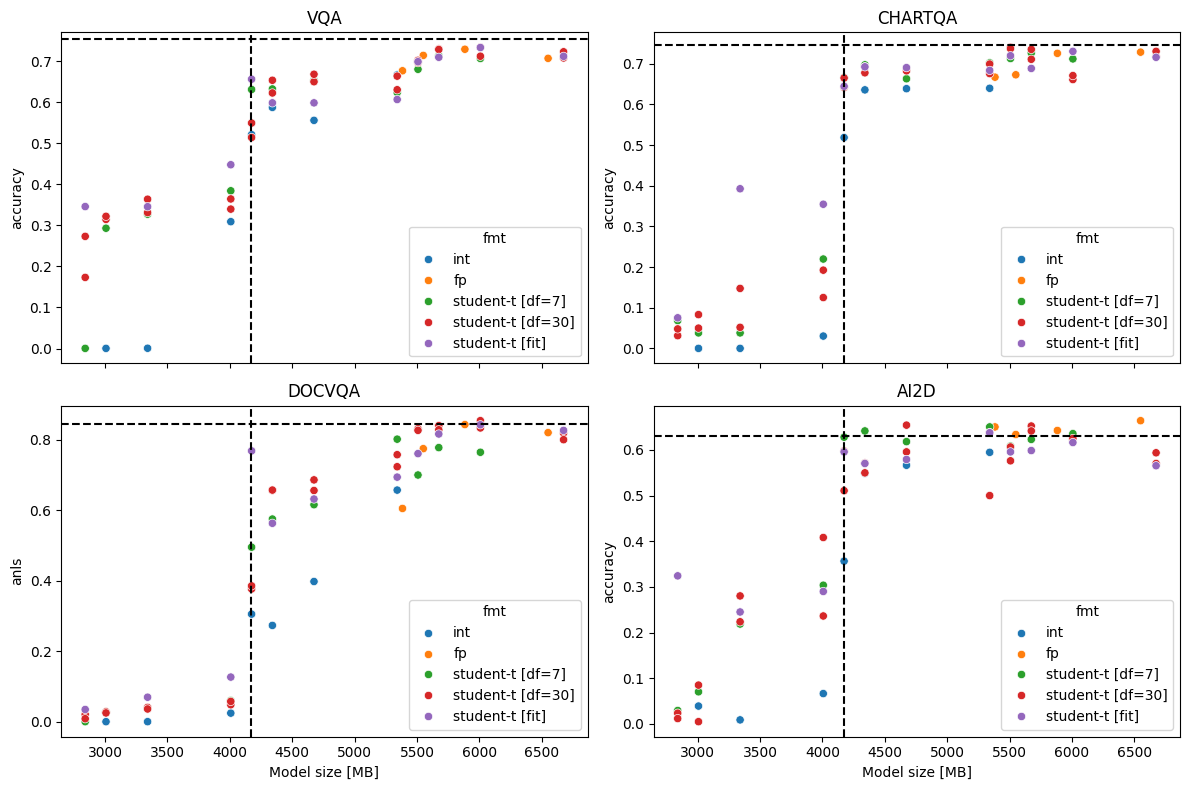

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for ax, task in zip(axes, tasks):
    sns.scatterplot(data=df, x="size", y=task, ax=ax, hue="fmt")
    
    ax.axhline(baseline[task][0], linestyle="--", color="black")
    ax.axvline(4170, linestyle="--", color="black")
    
    ax.set_title(task.upper())
    ax.set_xlabel("Model size [MB]")
    metrics = get_metrics(task)
    ax.set_ylabel(metrics[0])
    

plt.tight_layout()
plt.show()

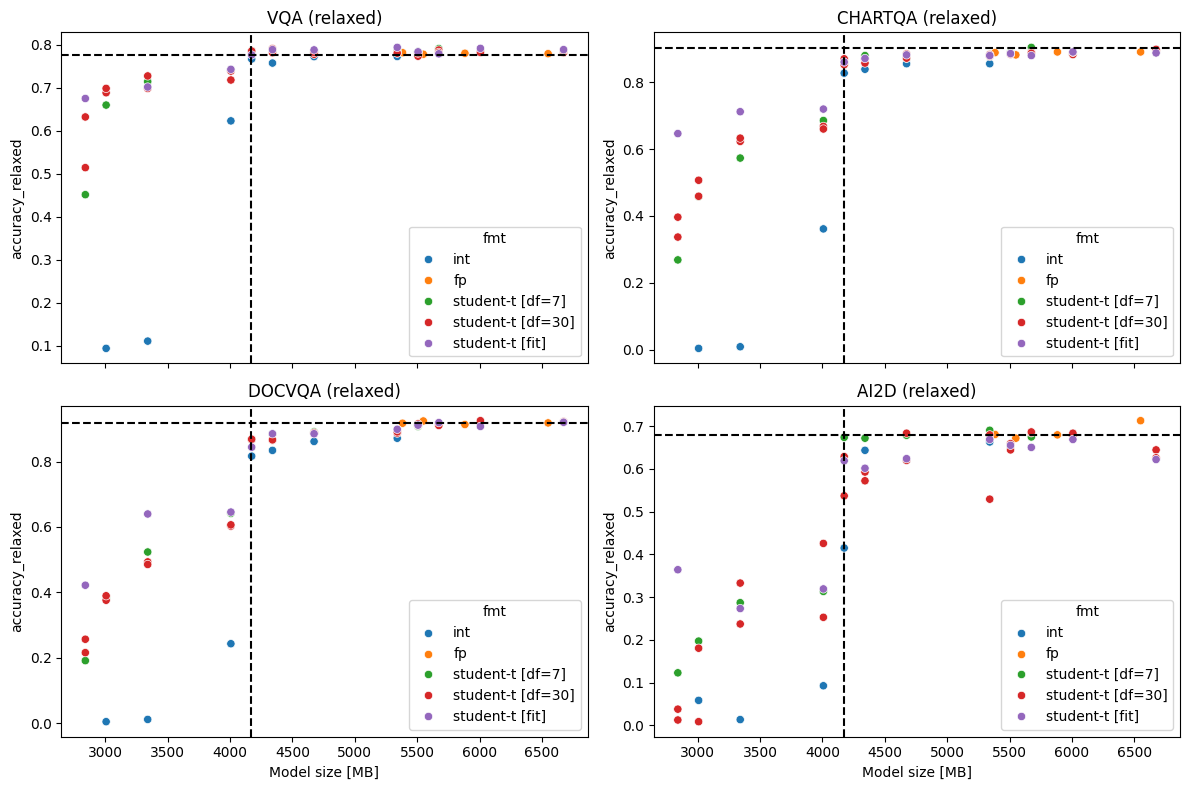

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for ax, task in zip(axes, tasks):
    sns.scatterplot(data=df, x="size", y=f"{task}_relaxed", ax=ax, hue="fmt")
    
    ax.axhline(baseline[task][1], linestyle="--", color="black")
    ax.axvline(4170, linestyle="--", color="black")
    
    ax.set_title(f"{task.upper()} (relaxed)")
    ax.set_xlabel("Model size [MB]")
    metrics = get_metrics(task)
    ax.set_ylabel(metrics[1])

plt.tight_layout()
plt.show()